# **SOLUTIONS FOR DEMONSTRATOR USE ONLY**

***

In [1]:
# Import Python package to display images in the notebook.
# Note if you run image cells the imge will disappear!
from IPython.display import Image, display

# SOLAR III - Solar Flares 
Now that we have explored the Sun's surface, we are going to dive in and focus on one particular solar phenomenon - solar flares!

<div class="alert alert-block alert-info">
    
**GOAL :** In this session we are going to look at solar flare events as light curves in varying wavelengths rather than as images. 

**AIM :** To understand how to access, manipulate and plot time series of solar flare events. 

**OUTPUT :** Create light curves in varying wavelengths of the same flare events using different instruments.
</div>

Solar flares are powerful, eruptive events that are seen across the entire **electromagnetic spectrum** (see below). They result from a build-up of magnetic energy that is converted into kinetic energy, thermal energy, and particle acceleration through **magnetic reconnection** (see below), where the magnetic field simplifies.

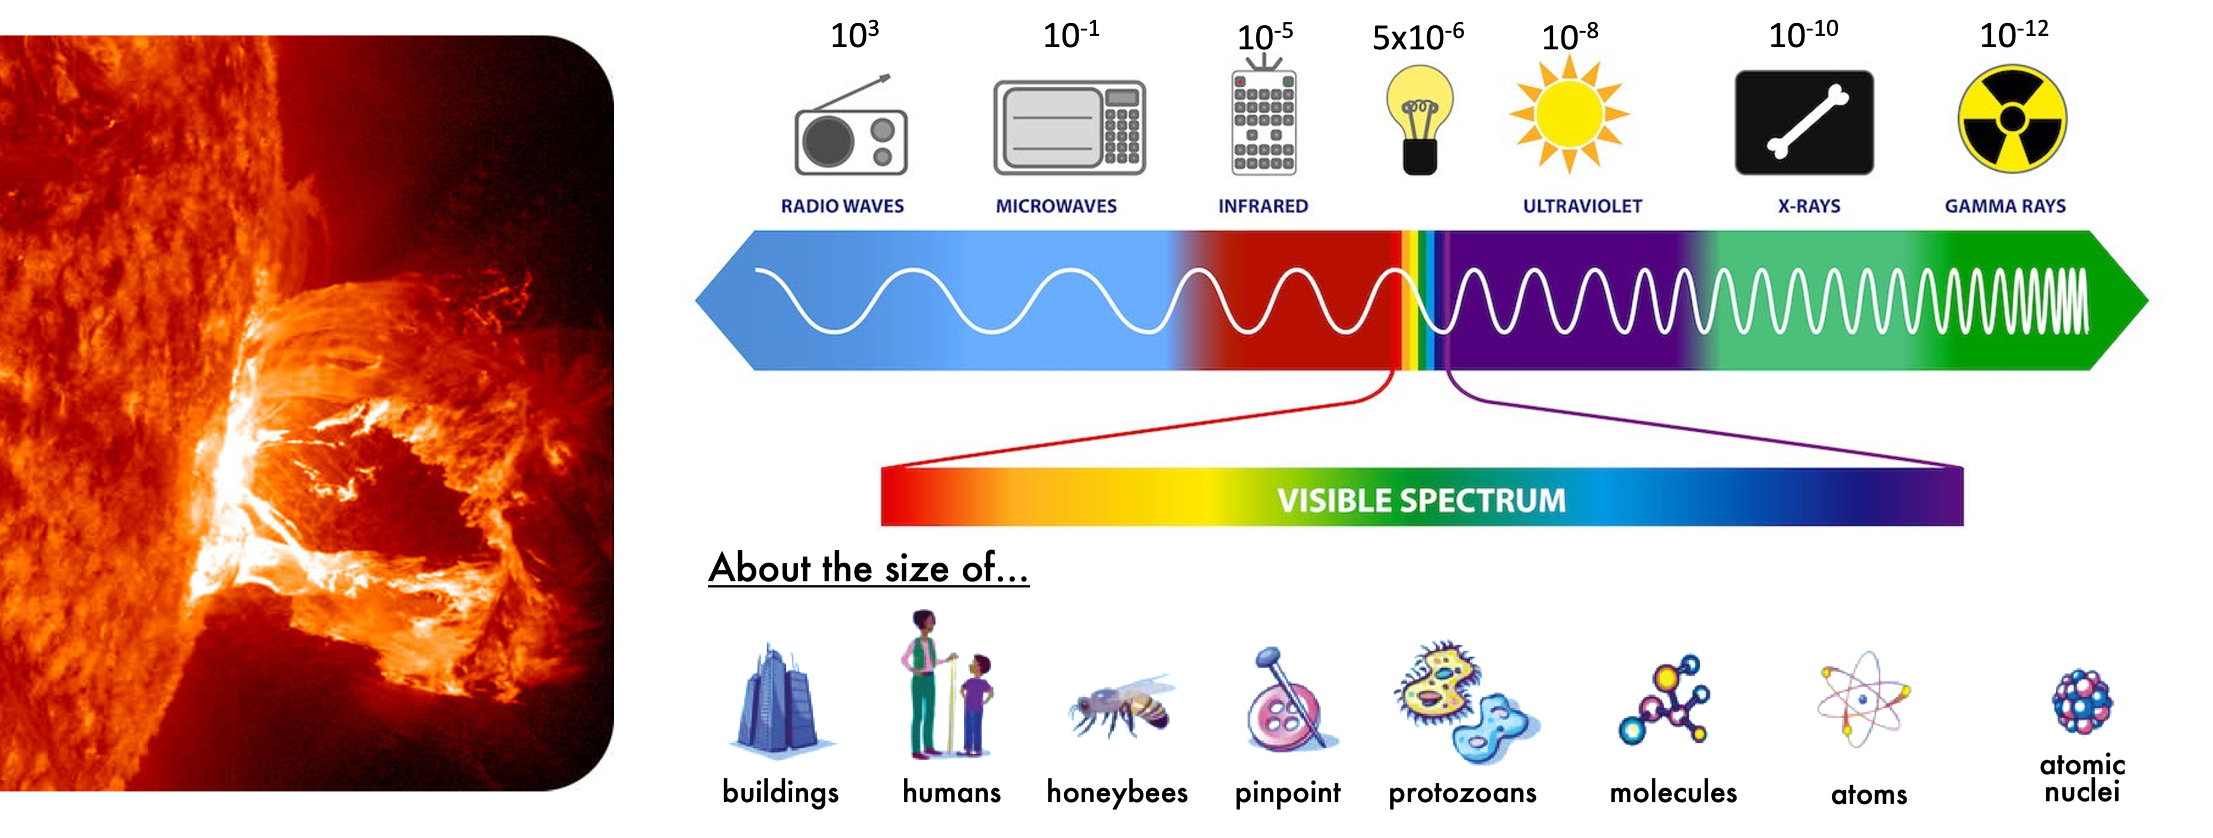

In [2]:
display(Image(filename="EM_spectrum_sun.png", embed=True))

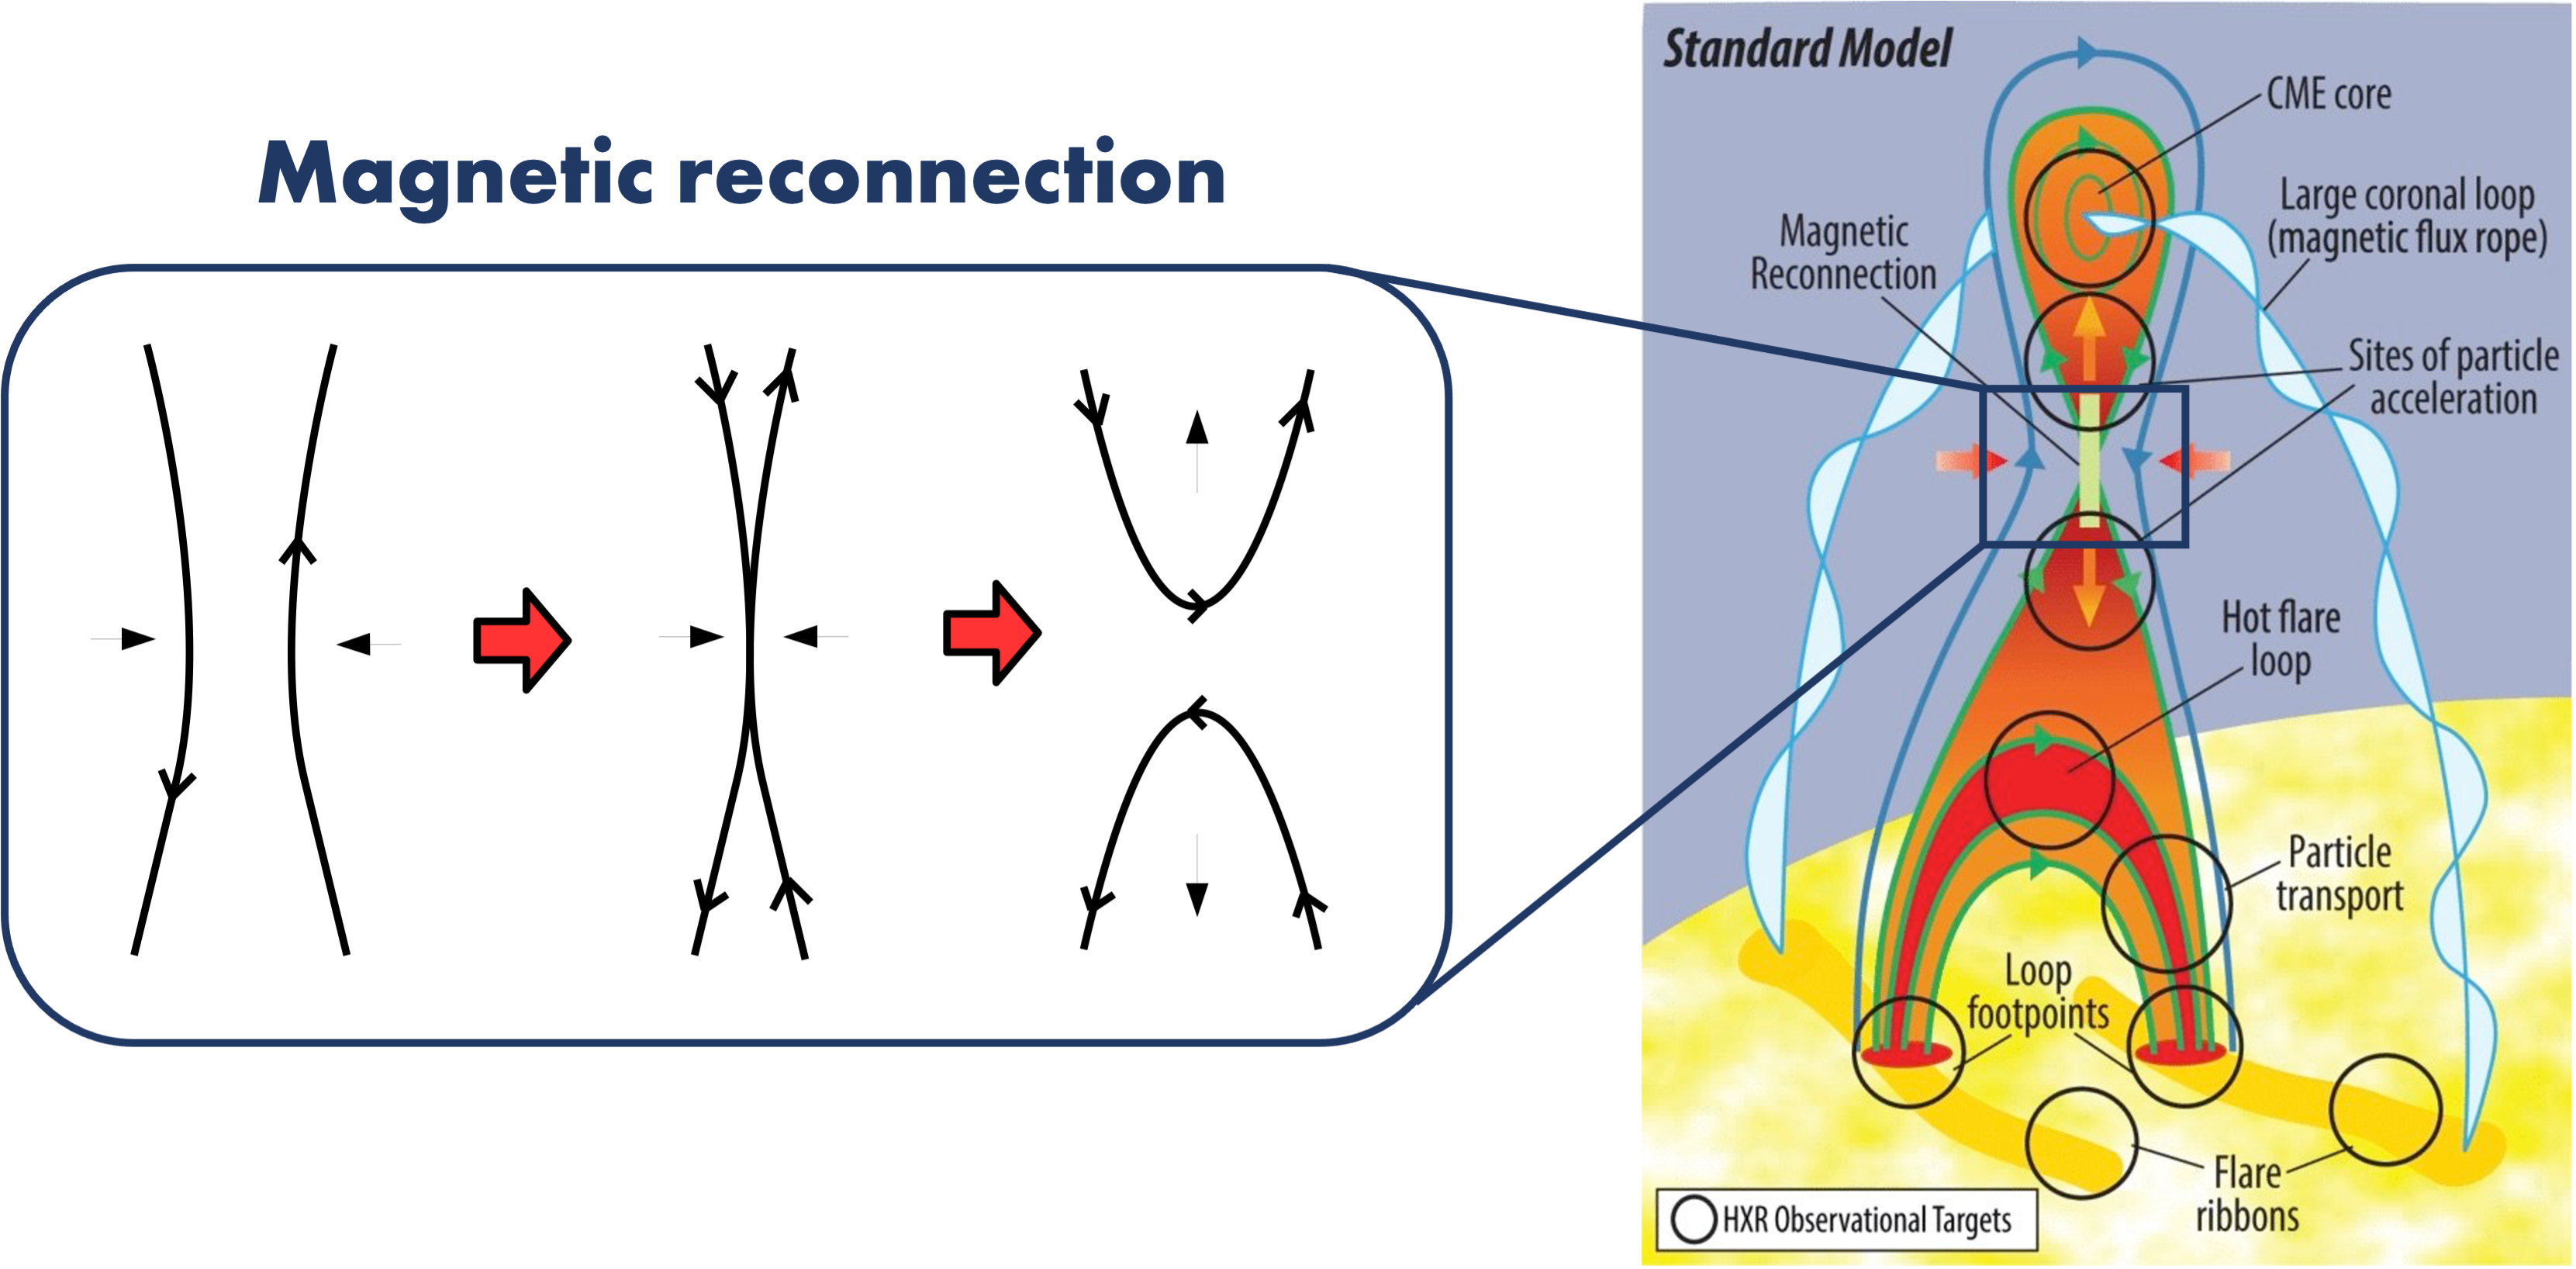

In [3]:
display(Image(filename="magnetic_reconnection.png", embed=True))

## Geostationary Operational Environmental Satellites (GOES)
Since 1975, the Geostationary Operational Environmental Satellites (GOES) have provided continuous imagery and data on atmospheric conditions and solar activity (space weather). They have even aided in the search and rescue of people in distress. GOES data products have enabled more accurate and timely weather forecasts and a better understanding of long-term climate conditions. GOES is a collaborative National Oceanic and Atmospheric Administration (NOAA) and NASA program where NASA builds and launches the satellites and NOAA operates them.

Over the years there have been 18 GOES satellites launched with three currently in operation. Since March 2020, GOES 15 is no longer taking data and GOES 16 and 17 have taken over with GOES 18 launched in March 2022. These three are part of the GOES-R series and provide XRS data at a better time resolution of one second.

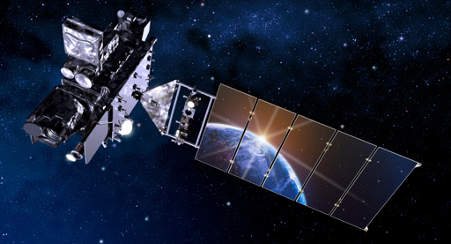

In [4]:
display(Image(filename="GOES.png", embed=True))

Large solar flares can change the Earth’s ionosphere, which blocks high-frequency radio transmissions on the sunlit side of the Earth. These events are also associated with Coronal Mass Ejections (CMEs), which can ultimately lead to geomagnetic storms. Some large solar flares are accompanied by strong radio bursts that may interfere with other radio frequencies and cause problems for satellite communication and radio navigation (GPS). 

Therefore, GOES uses its onboard X-Ray Sensors (XRS) to take measurements of solar X-rays in the 1-8 Å (long or xrsb channel) and 0.5-4.0 Å (short or xrsa channel) passbands, which are plotted (see example below) and used to track solar activity and solar flares. They then use these measurements to determine the strength of solar flare events, where thresholds (also called indices) are used by solar physicists to classify them. Flare indices are denoted by a letter and a number based on the log10 peak irradiance of the flare:

- X: 10<sup>-4</sup> W m-2
- M: 10<sup>-5</sup> W m-2
- C: 10<sup>-6</sup> W m-2
- B: 10<sup>-7</sup> W m-2
- A: 10<sup>-8</sup> W m-2

For example, an M5 index is defined for a 5x10<sup>-5</sup> Wm<sup>-2</sup> peak irradiance, and an X2.5 index is defined as an irradiance level of 2.5x10<sup>-4</sup> Wm<sup>-2</sup> peak irradiance. The flare index is defined by the truncated (not rounded) irradiance; e.g., a flare with peak irradiance of 4.19x10<sup>-5</sup> Wm<sup>-2</sup> is an M4.1 flare, not an M4.2 flare. The Space Weather Prediction Centre at NOAA sends out space weather alerts when flares at the M5 level or above are detected. 

Real-time data from GOES data can be found at this __[link](https://www.swpc.noaa.gov/products/goes-x-ray-flux)__.

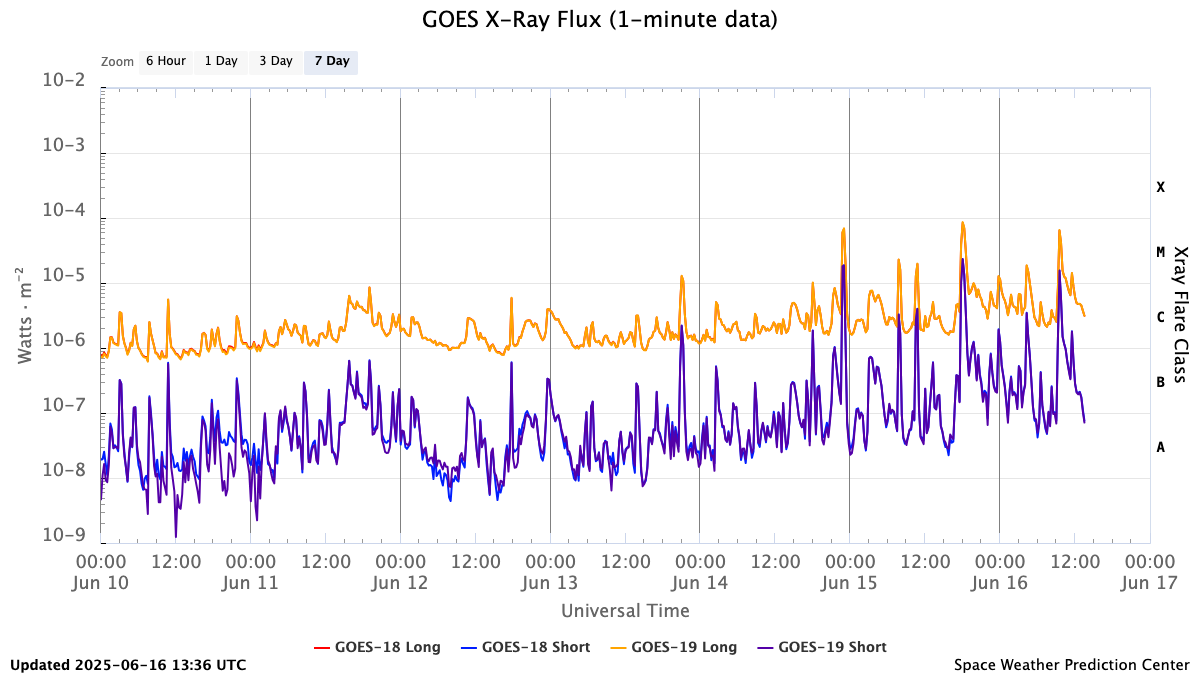

In [5]:
display(Image(filename="goes-x-ray-flux-1-minute.png", embed=True))

---
### Accessing GOES data using sunpy
Let's first add all the Python packages that we will need.

In [2]:
# some basic packages
import os
import sys
import fnmatch
import numpy as np
import pandas as pd

# solar physics package
import sunpy

# importing plotting packages
import matplotlib.pyplot as plt
from matplotlib import dates

# setting text size for plots
import matplotlib as mpl
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['axes.titlesize'] = 12
mpl.rcParams['axes.labelsize'] = 12

# importing widgets for interactive plots
from ipywidgets import *

For this session, we will be focusing on using `sunpy.timeseries` to create plots of GOES X-ray data, so we need to import the packages here. 

**Note:** If you have any errors with this, then ask a demonstrator, as you need to have all SunPy packages and their dependencies installed. 

In [3]:
# and some sub packages from sunpy and astropy
from sunpy import timeseries as ts
from sunpy.time import parse_time
from astropy import units as u

There are three ways to access GOES solar time series data.

1. Using __[GOES XRS Near Real Time data]( https://services.swpc.noaa.gov/json/goes/primary/)__, which includes the GOES XRS timeseries data as well as the flare times.
2. Accessing the __[Heliophysics Events Knowledgebase (HEK)](https://www.lmsal.com/hek/index.html)__ catalogue to retreive a list of all solar flare events. 
3. Retrieve the GOES XRS data using __[Fido](https://docs.sunpy.org/en/stable/generated/api/sunpy.net.Fido.html#sunpy.net.Fido)__, which we used earlier for downloading SDO data.

### Examples
### 1. Accessing GOES Near Real Time Data
The GOES Near Real Time data is accessed using `pandas.read_json()`. This allows us to download the file and load it directly into a `pandas.DataFrame`. This file updates every minute and contains the last 7 days worth of data. However, there is a little bit of work to do to get the data into a format which the `sunpy.timeseries` will accept. 

Download the data:
>`goes_data = pd.read_json("https://services.swpc.noaa.gov/json/goes/primary/xrays-7-day.json")`

The flux values vary between the two channels, so we need to rearrange them into two columns using a pivot table:
>`goes_data = goes_data.pivot(index='time_tag', columns='energy', values='observed_flux')`
>
> `goes_data.rename(columns={'0.05-0.4nm': 'xrsa', '0.1-0.8nm': 'xrsb'}, inplace=True)'`

To make a sunpy.timeseries we need a datetime index, which we can get by parsing the time strings:
> `goes_data.index = parse_time(list(goes_data.index)).datetime`

We also need to have units for each of the flux columns, so we will create a dictionary and map each column to units of 
> `units = dict([("xrsa", u.W / u.m ** 2), ("xrsb", u.W / u.m ** 2)])`

We also need to create a metadata dictionary for the data:
> `meta = dict({"instrument": "GOES X-ray sensor", "measurements": "primary", "type": "quicklook"})`

Now we can create a sunpy.timeseries.TimeSeries by passing in the data, metadata and units:
> `goes_ts = ts.TimeSeries(goes_data, meta, units, source="xrs")`

And plot the data using:
>`goes_ts.plot(axes=ax)`

NOAA also provides the past 7 days of flare event identifications, which we can also download:
> `flare_events = pd.read_json("https://services.swpc.noaa.gov/json/goes/primary/xray-flares-7-day.json")`


## Task III-1
- Using the example above, download and plot the past 7 days of GOES Near Real Time data.
- Download the flare event identifications list and identify the five largest flares in the past seven days. (**Tip:** sort the data using `sort_values` function in `pandas`. Then consider slicing by rows, __[as shown here](https://datacarpentry.github.io/python-ecology-lesson/03-index-slice-subset.html#slicing-subsets-of-rows-in-python)__).
- Overplot the five largest flares onto the GOES timeseries. (**Tip:** consider using `axvline` from `matplotlib` to plot vertical lines).

## SOLUTIONS

Text(0.5, 1.0, 'Last 7 days of GOES XRS data')

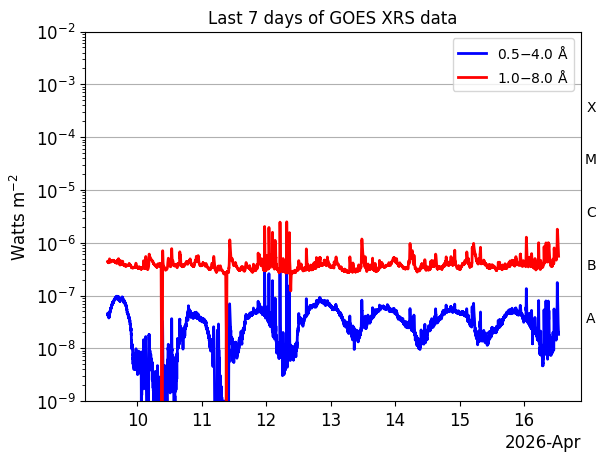

In [4]:
# download the data
goes_data = pd.read_json("https://services.swpc.noaa.gov/json/goes/primary/xrays-7-day.json")

# rearrange data. 
goes_data = goes_data.pivot(index='time_tag', columns='energy', values='observed_flux')
goes_data.rename(columns={'0.05-0.4nm': 'xrsa', '0.1-0.8nm': 'xrsb'}, inplace=True)

# set up and create a timeseries.
goes_data.index = parse_time(list(goes_data.index)).datetime
units = dict([("xrsa", u.W / u.m ** 2), ("xrsb", u.W / u.m ** 2)])
meta = dict({"instrument": "GOES X-ray sensor", "measurements": "primary", "type": "quicklook"})
goes_ts = ts.TimeSeries(goes_data, meta, units, source="xrs")

# plotting the GOES timeseries. 
fig, ax = plt.subplots()
goes_ts.plot(axes=ax)
ax.set_title(f"Last 7 days of GOES XRS data")

In [6]:
# download the flare event identification list for the past seven days. 
flare_events = pd.read_json("https://services.swpc.noaa.gov/json/goes/primary/xray-flares-7-day.json")
#print(flare_events)

In [7]:
# sort the flare list from the highest X-ray output to lowest
if len(flare_events) > 0:
    sort_flares = flare_events.sort_values('max_xrlong', ascending=False)

# select the five largest flares from the list. 
largest_flares = sort_flares[:5]
print(largest_flares)

                time_tag                begin_time begin_class  \
17  2026-04-12T07:31:00Z 2026-04-12 07:31:00+00:00        B3.4   
15  2026-04-12T04:55:00Z 2026-04-12 04:55:00+00:00        B2.6   
8   2026-04-11T23:15:00Z 2026-04-11 23:15:00+00:00        B2.5   
10  2026-04-12T00:47:00Z 2026-04-12 00:47:00+00:00        B2.8   
54  2026-04-16T12:16:00Z 2026-04-16 12:16:00+00:00        B8.0   

                    max_time max_class  max_xrlong  max_ratio  \
17 2026-04-12 07:38:00+00:00      C2.4    0.000002   0.133429   
15 2026-04-12 05:08:00+00:00      C2.4    0.000002   0.142254   
8  2026-04-11 23:24:00+00:00      C1.9    0.000002   0.347581   
10 2026-04-12 01:01:00+00:00      C1.9    0.000002   0.158519   
54 2026-04-16 12:25:00+00:00      C1.7    0.000002   0.146288   

              max_ratio_time  current_int_xrlong                  end_time  \
17 2026-04-12 07:37:13+00:00            0.000918 2026-04-12 07:41:00+00:00   
15 2026-04-12 05:05:05+00:00            0.001040 2026-04

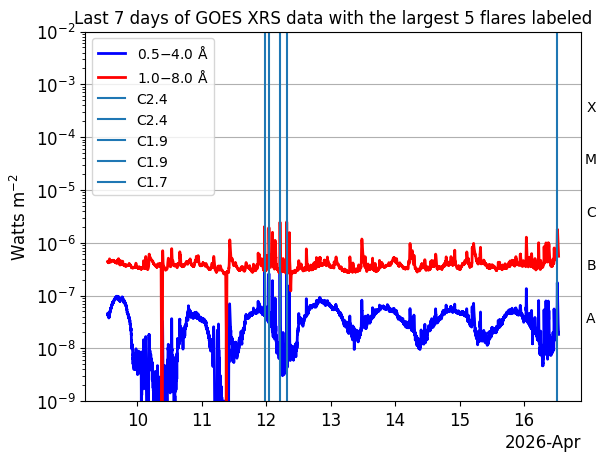

In [8]:
fig, ax = plt.subplots()
goes_ts.plot(axes=ax)
for _, this_flare in largest_flares.iterrows():
    ax.axvline(this_flare["max_time"], label=f'{this_flare["max_class"]}')
ax.legend(loc = 'best')
ax.set_title(f"Last 7 days of GOES XRS data with the largest 5 flares labeled")
plt.show()

---
### 2. Accessing GOES flare event list
First, let's import the Fido package within SunPy that we will need.
```python
from sunpy.net import Fido
from sunpy.net import attrs as a
```

We use Fido to query the __[Heliophysics Events Knowledgebase (HEK)](https://www.lmsal.com/hek/index.html)__ catalogue. We define our event type as a flare (“FL”). We also set up the start and end times over which we will search for flare events. We want a list of events that were detected by GOES between tstart and tend and have a class > M1.0.

```python
event_type = "FL"
tstart = "2013/10/28"
tend = "2013/10/29"
result = Fido.search(a.Time(tstart, tend),
                     a.hek.EventType(event_type),
                     a.hek.FL.GOESCls > "M1.0",
                     a.hek.OBS.Observatory == "GOES")
```

The result is returned as a UnifiedResponse, from which we can see that a table from one provider is found and returned. Using this, we only show two columns as there are over 100 columns returned normally.

```python
print(result.show("hpc_bbox", "refs"))
```

It is also possible to access the HEK results from the `~sunpy.net.fido_factory.UnifiedResponse` by name.

```python
hek_results = result["hek"]
```
The results returned contain a lot of information, and we may only want to keep some main results, such as start time, end time, peak time, GOES-class, and active region number. 

## Task III-2
- Using Example 2 above, create an up-to-date list of all GOES solar flare events from the period **30th April 2024 - 12th May 2024**.
- Filter these results to show key flare properties. (**Tip:** Consider using slicing by column labels, __[as shown here](https://datacarpentry.github.io/python-ecology-lesson/03-index-slice-subset.html#selecting-data-using-labels-column-headings)__. Column labels are `"event_starttime", "event_peaktime","event_endtime", "fl_goescls", "ar_noaanum"`) 
- Identify the **two** largest flare in your list by eye, noting the flare start and end time. Using the flare classification from earlier, determine the energy of these flares in Wm<sup>-2</sup>. 

## SOLUTIONS

In [31]:
# import Fido and attributes
from sunpy.net import Fido
from sunpy.net import attrs as a

# getting the flare list over the period 30th April - 12th May 2024. 
event_type = "FL"
tstart = "2024/04/30"
tend = "2024/05/12"
flare_events = Fido.search(a.Time(tstart, tend),
                     a.hek.EventType(event_type),
                     a.hek.FL.GOESCls > "M1.0",
                     a.hek.OBS.Observatory == "GOES")

# extracting the hek flare properties
hek_flare_prop = flare_events["hek"]
#print(hek_flare_prop)

In [32]:
# filtering the hek flare properties to only include the ones required
filtered_flare_prop = hek_flare_prop["event_starttime", "event_peaktime","event_endtime", "fl_goescls", "ar_noaanum"]
print(filtered_flare_prop)

    event_starttime          event_peaktime          event_endtime      fl_goescls ar_noaanum
----------------------- ----------------------- ----------------------- ---------- ----------
2024-04-30 00:46:00.000 2024-04-30 01:14:00.000 2024-04-30 01:31:00.000       M1.6      13654
2024-04-30 14:50:00.000 2024-04-30 15:11:00.000 2024-04-30 15:26:00.000       M1.2      13654
2024-04-30 16:11:00.000 2024-04-30 16:33:00.000 2024-04-30 16:47:00.000       M1.3      13654
2024-04-30 23:23:00.000 2024-04-30 23:46:00.000 2024-04-30 23:58:00.000       M9.5      13654
2024-05-01 14:17:00.000 2024-05-01 14:32:00.000 2024-05-01 14:37:00.000       M1.8      13654
2024-05-01 14:37:00.000 2024-05-01 14:44:00.000 2024-05-01 14:48:00.000       M1.9      13654
2024-05-01 22:26:00.000 2024-05-01 22:31:00.000 2024-05-01 22:37:00.000       M1.8      13663
2024-05-02 20:52:00.000 2024-05-02 20:57:00.000 2024-05-02 21:01:00.000       M2.7      13664
2024-05-03 00:08:00.000 2024-05-03 00:15:00.000 2024-05-03 0

The largest flare:
- Date/Time: **08/05/2024 21:08 - 22:05 UT**  
- Flare Classification: **X9.0** 
- Flare energy: **9.0 x 10<sup>-4</sup> Wm<sup>-2</sup>**

The second largest flare:
- Date/Time: **11/05/2024 01:10 - 01:40 UT**  
- Flare Classification: **X5.8** 
- Flare energy: **5.8 x 10<sup>-4</sup> Wm<sup>-2</sup>**

<div class="alert alert-block alert-warning">
<b>CHECKPOINT 1:</b> Find a demonstrator and show them your flare list before progressing to the next task.
</div>

---
### 3. Accessing GOES data using Fido
First lets import the Fido package within sunpy we will need.
```python
from sunpy.net import Fido
from sunpy.net import attrs as a
```
A quick reminder, when searching for data with Fido, you need to specify attributes to search with (similar to what we did with SDO data in the previous session). We will use the following for GOES data:

- use a.Time to specify the data and time in the format 'yyyy/mm/dd hh:mm:ss'

```python
e.g. a.Time('2025/10/01 00:00:15', '2025/10/01 00:00:30')
```

- use the a.Instrument to specify which instrument you would like (i.e. XRS for GOES data)

```python
e.g. a.Instrument("AIA")
```

For example, we define our start and end times and query the XRS database using Fido as follows. 
```python
tstart = "2015-06-21 01:00"
tend = "2015-06-21 23:00"
result = Fido.search(a.Time(tstart, tend), a.Instrument("XRS"))
print(result)
```
This returns six results, two files for each of GOES 13, GOES 14 and GOES 15, which can be identified by the `SatelliteNumber` column. The GOES data provided can either be high-cadence (1s/2s/3s based on the GOES satellite) or averaged over 1 minute. This can be noted in the Resolution column, where the `avg1m` and `flx1s` attributes are the 1-minute average and the high-cadence data, respectively. 

However, we only want one of these files for our analysis, so we filter our query further using the following attributes:

- use a.goes.SatelliteNumber to specify what GOES satellite number you want to use (see notes at beginning)
```python
e.g a.goes.SatelliteNumber(15)
```

- use a.Resolution to specify the resolution (or cadence) of the observations (see notes at beginning)
```python
e.g a.Resolution("flx1s")
```

We can now refine our Fido query to specify the GOES-15 satellite and use the high-cadence observations.
```python
result_goes15 = Fido.search(a.Time(tstart, tend), a.Instrument("XRS"), a.goes.SatelliteNumber(15), a.Resolution("flx1s"))
print(result_goes15)
```

Now download this using fetch:
```python
file_goes15 = Fido.fetch(result_goes15, path='/your/path/here/{file}')
```

We can load this into a TimeSeries, and inspect the data using `peek()`:
```python
goes_15 = ts.TimeSeries(file_goes15)
goes_15.peek()
```

The GOES quality flags can be used to filter GOES data. These tell us about the quality of the data and remove any points which may have instrumental issues with pointing or calibration. 

```python
df = goes_15.to_dataframe()
df = df[(df["xrsa_quality"] == 0) & (df["xrsb_quality"] == 0)]
goes_15 = ts.TimeSeries(df, goes_15.meta, goes_15.units)
```

We can also pull out the individual GOES channels and plot them separately by specifying the `column`. 

```python
goes_1.peek(axes=ax, columns=["xrsb"])
```


## Task III-3
- Plot the GOES light curve for one of the largest solar flares identified in Task III-2, accessing the data using Fido.
- Using `axvline` from `matplotlib`, add vertical dashed lines with the flare start, end and peak time. 

## SOLUTIONS

In [58]:
# collecting GOES data for X5.8 flare on 11/05/2024
tstart = "2024-05-11 01:00"
tend = "2024-05-11 23:00"
result_goes = Fido.search(a.Time(tstart, tend), a.Instrument("XRS"), a.goes.SatelliteNumber(18), a.Resolution("flx1s"))
print(result_goes)

# downloading data, adding to dataframe
flare = Fido.fetch(result_goes, path='/Users/u1973287/OneDrive - University of Warwick/Outreach/ThaiPASS/data/III_data/{file}')
goes = ts.TimeSeries(flare)
df = goes.to_dataframe()
df = df[(df["xrsa_quality"] == 0) & (df["xrsb_quality"] == 0)]
goes = ts.TimeSeries(df, goes.meta, goes.units)

Results from 1 Provider:

1 Results from the XRSClient:
Source: <8: https://umbra.nascom.nasa.gov/goes/fits 
8-15: https://www.ncei.noaa.gov/data/goes-space-environment-monitor/access/science/ 
16-17: https://data.ngdc.noaa.gov/platforms/solar-space-observing-satellites/goes/

       Start Time               End Time        Instrument  Physobs   Source Provider Resolution SatelliteNumber
----------------------- ----------------------- ---------- ---------- ------ -------- ---------- ---------------
2024-05-11 00:00:00.000 2024-05-11 23:59:59.999        XRS irradiance   GOES     NOAA      flx1s              18




Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

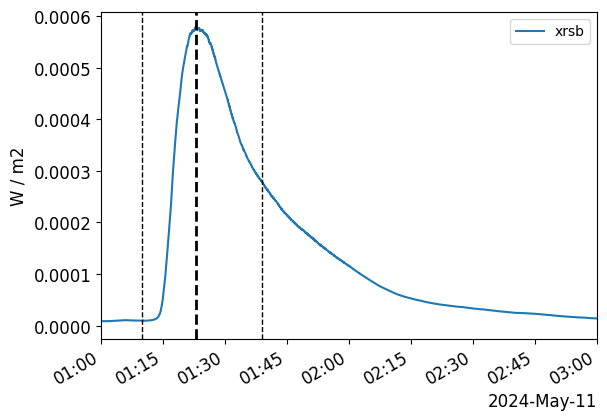

In [64]:
# plotting the flare
fig, ax = plt.subplots()
goes.plot(axes=ax, columns=["xrsb"])
ax.axvline(x = '2024-05-11 01:10:00', linestyle = '--', linewidth = 1, color = 'k')
ax.axvline(x = '2024-05-11 01:23:00', linestyle = '--', linewidth = 2, color = 'k')
ax.axvline(x = '2024-05-11 01:39:00', linestyle = '--', linewidth = 1, color = 'k')
ax.set_xlim(['2024-05-11 01:00:00','2024-05-11 03:00:00'])
plt.show()

<div class="alert alert-block alert-warning">
<b>CHECKPOINT 2:</b> Find a demonstrator and show them your GOES light curve before progressing to the next task.
</div>

---
## Extreme ultraviolet Variability Experiment (EVE)

The Extreme ultraviolet Variability Experiment (EVE) is the third instrument on board the Solar Dynamics Observatory (SDO). EVE records the Sun’s extreme ultraviolet (EUV) radiation — light with very short wavelengths (roughly 0.1 to 105 nm) that we cannot see with our eyes. EUV radiation comes from the Sun’s hot upper atmosphere (the corona) and changes quickly during solar flares and other magnetic activity. Even small changes in EUV output can strongly affect Earth’s upper atmosphere, ionosphere, and satellite communications.

What makes EVE special:
- It takes measurements every 10 seconds, so it can follow rapid solar events in detail.
- It provides a full EUV spectrum — allowing scientists to study how different layers of the solar atmosphere respond during flares.
- Its continuous, high-cadence data set is one of the most complete records of solar EUV variability we have.

By using EVE data, you can directly see how solar flares brighten the EUV spectrum and compare this behaviour with soft X-ray data from the GOES satellites. This helps build a picture of how solar activity is detected across different wavelengths.

### Accessing EVE data using SunPy
This is done using Fido, same as above for GOES data, but the instrument should be changed to `a.Instrument("EVE")`. We also want to focus on the level 1 data, which can be filtered using the `a.Level.one` attribute. 

In the EVE/ESP broadband Level-1 data product:
- –1 values are fill values inserted whenever the instrument has no valid measurement (e.g. during eclipses, spacecraft manoeuvers, or bad packets).
- They aren’t real negative irradiances — they’re just placeholders that mean “ignore this data point”.

Therefore, we need to clean these out. The code below provides a definition which does this for you; it takes the timeseries as an input and returns the cleaned (i.e. all -1 values removed) data as a new timeseries. 

In [66]:
import numpy as np
from sunpy.timeseries import GenericTimeSeries
from sunpy.util.metadata import MetaDict

def clean_timeseries(ts, fill_value=-1):
    """
    Clean a SunPy TimeSeries by replacing fill values with NaN,
    while preserving units and metadata.
    
    Parameters
    ----------
    ts : sunpy.timeseries.TimeSeries
        The original timeseries object (e.g. from Fido.fetch).
    fill_value : int or float, optional
        Value used in the data to represent missing points (default = -1).
    
    Returns
    -------
    ts_clean : sunpy.timeseries.GenericTimeSeries
        A cleaned timeseries with fill values replaced by NaN,
        and units/metadata preserved.
    """
    # Convert to DataFrame and replace fill values
    df = ts.to_dataframe().replace(fill_value, np.nan)
    #The timestamps can be misconstructed when read into Python, correct for this offset. 
    df.index = df.index - pd.Timedelta(hours=12)

    # Preserve units if available
    units = getattr(ts, "units", None)

    # Preserve metadata if possible
    meta = getattr(ts, "meta", None)
    if hasattr(meta, "to_dict"):
        meta = meta.to_dict()
    if isinstance(meta, dict):
        meta = MetaDict(meta)
    else:
        meta = None

    # Build a new GenericTimeSeries
    kwargs = {}
    if units is not None:
        kwargs["units"] = units
    if meta is not None:
        kwargs["meta"] = meta

    return GenericTimeSeries(data=df, **kwargs)

## Task III-4
- For the flare plotted in Task III-3, download and clean the corresponding EVE data.
- Place it into a timeseries and create a plot. 

## SOLUTIONS

Results from 1 Provider:

1 Results from the VSOClient:
Source: https://sdac.virtualsolar.org/cgi/search
Data retrieval status: https://docs.virtualsolar.org/wiki/VSOHealthReport

       Start Time               End Time        Source Instrument  Wavelength  Provider  Physobs   Extent Type   Size  
                                                                    Angstrom                                    Mibyte 
----------------------- ----------------------- ------ ---------- ------------ -------- ---------- ----------- --------
2024-05-11 00:00:00.000 2024-05-12 00:00:00.000    SDO        EVE 1.0 .. 304.0     LASP irradiance    FULLDISK -0.00098




Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

<Axes: ylabel='W / m2'>

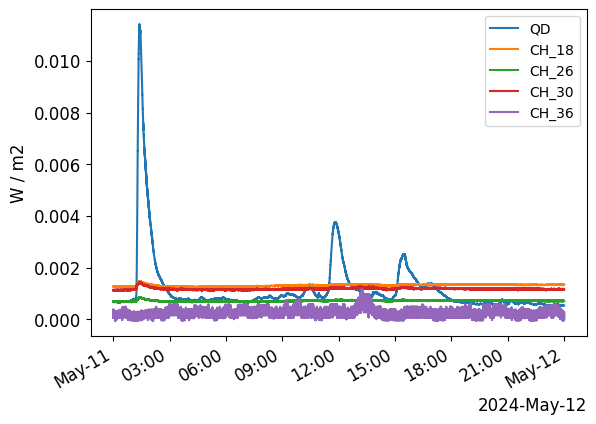

In [68]:
# downloading the EVE Level-1 data
tstart = "2024-05-11 01:00"
tend = "2024-05-11 02:00"
result_eve = Fido.search(a.Time(tstart, tend), a.Instrument("EVE"), a.Level.one)
print(result_eve)

# download the data
data = Fido.fetch(result_eve, path='/Users/u1973287/OneDrive - University of Warwick/Outreach/ThaiPASS/data/III_data/{file}')
eve = ts.TimeSeries(data)

# clean data using function:
eve_clean = clean_timeseries(eve)

# or crudely by:
#df = eve.to_dataframe().replace(-1, np.nan)
#eve_clean = ts.TimeSeries(df)

eve_clean.plot()

When looking at your plots, you will notice there is data present from different channels. The Extreme ultraviolet Spectro-Photometer (ESP) is an irradiance instrument which is part of EVE on board SDO. ESP provides high time cadence (0.25s) EUV irradiance measurements in five channels, one soft X-ray and 4 EUV as follows:
- ‘QD’ - sum of 4 quad diodes, this is the soft X-ray measurements 0.1-7nm
- ‘CH_18’ - EUV irradiance 18nm
- ‘CH_26’ - EUV irradiance 26nm
- ‘CH_30’ - EUV irradiance 30nm
- ‘CH_36’ - EUV irradiance 36nm

Each channel is stored as a separate column. Column names may vary; therefore, we can list them within the EVE timeseries for inspection using: 

>`eve_cols = [c for c in eve_ts.columns if isinstance(c, str)]`

## Task III-5
- For the flare events used in the previous task, plot each of the EVE ESP channels in a separate subplot so they can be seen more clearly.
- Make sure there are axis labels and a title.

**Tip:** You can use timeseries or a dataframe

## SOLUTIONS

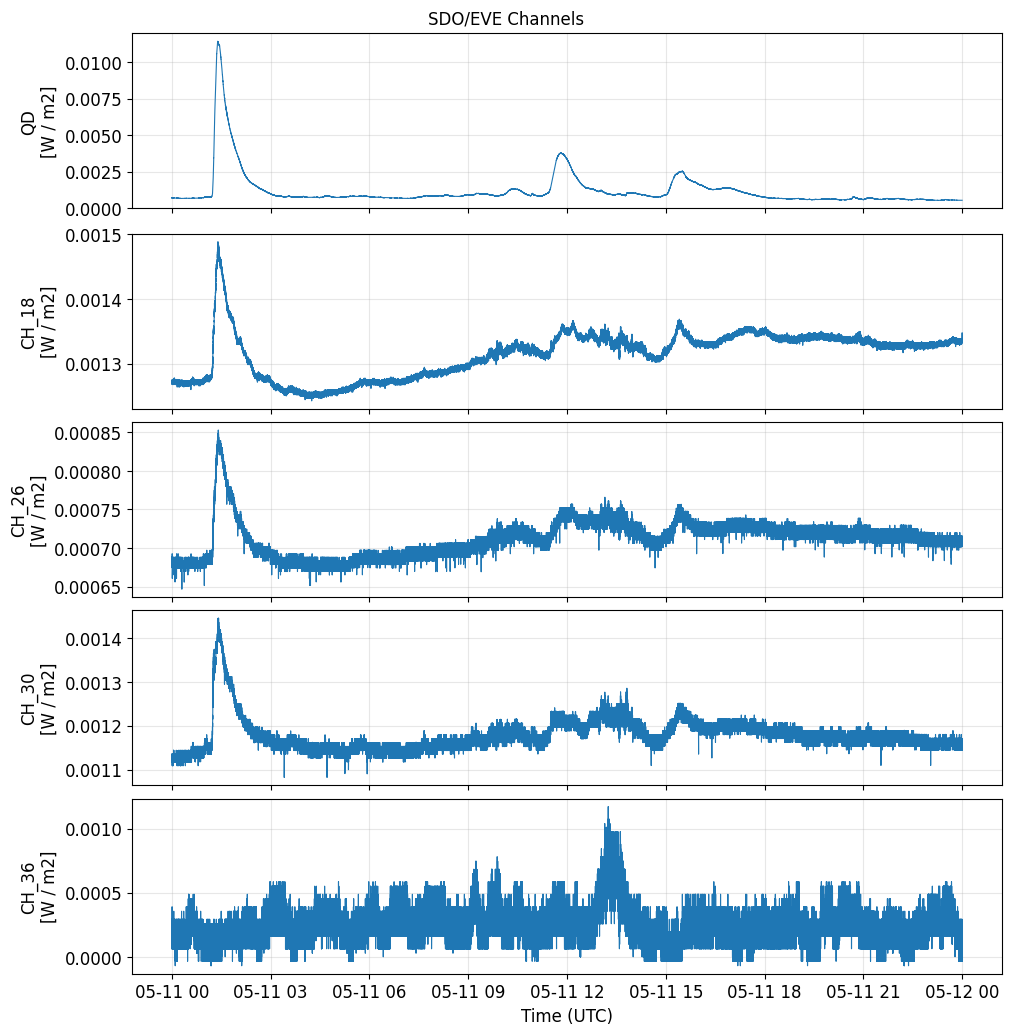

In [69]:
eve_df = eve_clean.to_dataframe()

channels = [c for c in eve_df.columns]
nch = len(channels)

fig, axes = plt.subplots(nch, 1, figsize=(10, 2*nch), sharex=True, constrained_layout=True)
for ax, col in zip(axes, channels):
    ax.plot(eve_df.index, eve_df[col], lw=0.8)
    ax.set_ylabel(f"{col}\n[{eve_clean.units.get(col, '')}]")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Time (UTC)")
fig.suptitle("SDO/EVE Channels", y=1.02)
plt.show()

<div class="alert alert-block alert-warning">
<b>CHECKPOINT 3:</b> Find a demonstrator and show them your EVE light curves before progressing to the next task.
</div>

### Comparing GOES and EVE solar flare light curves

The example code below normalises the GOES and EVE timeseries so they can be easily plotted together on one plot. 

In [70]:
def normalize(s):
    # function to normalise data.
    arr = np.array(s, dtype=float)
    return (arr - np.nanmin(arr)) / (np.nanmax(arr) - np.nanmin(arr) + 1e-15)

## Task III-6 (Optional)
- Using the same solar flare as previous tasks, create a GOES and EVE light curve comparison plot. 

## SOLUTIONS

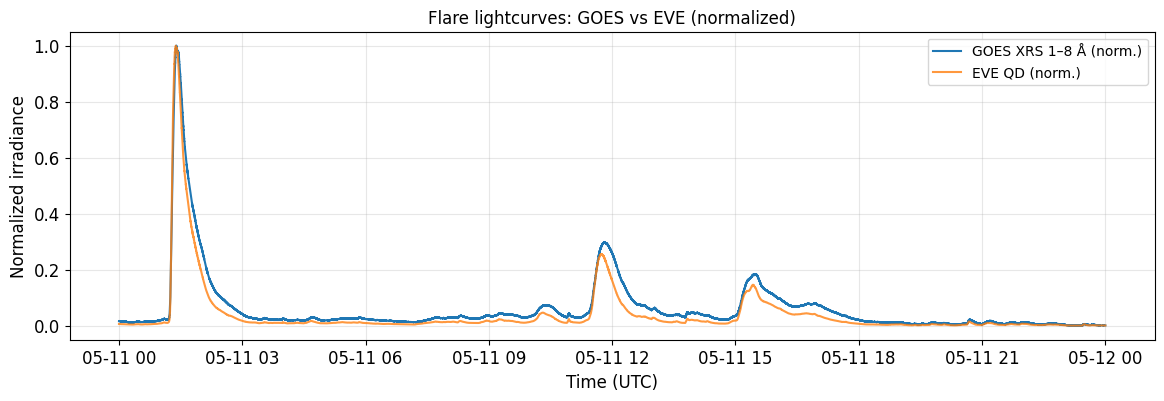

In [71]:
#normalise_eve
df_eve = eve_clean.to_dataframe()
normalise_eve = normalize(df_eve.QD)

# normalise goes
df_goes = goes.to_dataframe()
normalise_goes = normalize(df_goes.xrsb)

fig, ax = plt.subplots(figsize=(14,4))
ax.plot(df_eve.index, normalise_eve, label="GOES XRS 1–8 Å (norm.)")
ax.plot(df_goes.index, normalise_goes, label=f"EVE QD (norm.)", alpha=0.8)
ax.set_title("Flare lightcurves: GOES vs EVE (normalized)")
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("Normalized irradiance")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## Task III-7 (Optional)
- Does EVE peak earlier or later than GOES? What might that suggest about flare heating and emission at different wavelengths?
- How does the shape of the EVE curve compare to GOES (sharper rise, slower decay)?

## SOLUTIONS

- Students may notice the UV/EUV rise is earlier or sharper, while X-rays peak later and decay more smoothly.
    Different layers of the solar atmosphere respond differently:

- EUV/UV emission comes from the chromosphere and transition region, which heat up almost instantly when energy is dumped into the lower atmosphere.

- X-rays come from the hot coronal plasma, which takes longer to build up and cool down.

This timing difference illustrates the Neupert effect: the idea that the cumulative heating from the impulsive phase (seen in UV/EUV or radio) drives the coronal plasma that produces the soft X-ray emission.

**Key message for students:** By comparing flare peaks in different wavelengths, we learn that a solar flare is a chain of events: fast energy release in the lower atmosphere → heating of plasma → bright coronal X-ray emission.

<div class="alert alert-block alert-warning">
<b>CHECKPOINT 4:</b> Find a demonstrator and discuss your GOES/EVE comparisson with them. 
</div>